In [1]:
# Cell 0 — Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)
np.random.seed(42)  # reproducibility

print("✅ Ready — NumPy:", np.__version__, "| Pandas:", pd.__version__)


✅ Ready — NumPy: 2.0.2 | Pandas: 2.2.2


In [2]:
# Cell 1 — Exercise 1: eigenvalues/eigenvectors + normalization
# Create a 5x5 matrix with random values
M = np.random.randn(5, 5)
print("Matrix M:\n", M)

# 1) Eigenvalues & eigenvectors (for a general square matrix)
eigvals, eigvecs = np.linalg.eig(M)
print("\nEigenvalues:\n", eigvals)
print("\nEigenvectors (columns correspond to eigenvalues):\n", eigvecs)

# 2) Matrix normalization
# Two common techniques:
#   a) Z-score normalization per column: (x - mean) / std
#   b) Min–Max scaling per column to [0, 1]
col_mean = M.mean(axis=0)
col_std  = M.std(axis=0, ddof=0)
M_zscore = (M - col_mean) / np.where(col_std == 0, 1, col_std)

col_min = M.min(axis=0)
col_max = M.max(axis=0)
rng = np.where((col_max - col_min) == 0, 1, (col_max - col_min))
M_minmax = (M - col_min) / rng

print("\nZ-score normalized (per column):\n", M_zscore)
print("\nMin–Max scaled to [0,1] (per column):\n", M_minmax)


Matrix M:
 [[ 0.4967 -0.1383  0.6477  1.523  -0.2342]
 [-0.2341  1.5792  0.7674 -0.4695  0.5426]
 [-0.4634 -0.4657  0.242  -1.9133 -1.7249]
 [-0.5623 -1.0128  0.3142 -0.908  -1.4123]
 [ 1.4656 -0.2258  0.0675 -1.4247 -0.5444]]

Eigenvalues:
 [ 1.8367+0.j      0.6544+1.4368j  0.6544-1.4368j -1.7977+0.j
 -0.4823+0.j    ]

Eigenvectors (columns correspond to eigenvalues):
 [[ 0.243 +0.j      0.6403+0.j      0.6403-0.j     -0.3145+0.j
   0.1844+0.j    ]
 [-0.9234+0.j     -0.0331+0.145j  -0.0331-0.145j  -0.2266+0.j
   0.4417+0.j    ]
 [-0.1732+0.j     -0.0259+0.368j  -0.0259-0.368j   0.6422+0.j
  -0.6575+0.j    ]
 [ 0.2191+0.j      0.0831+0.3797j  0.0831-0.3797j  0.2728+0.j
   0.1134+0.j    ]
 [ 0.1011+0.j      0.0574-0.5267j  0.0574+0.5267j  0.6025+0.j
  -0.5707+0.j    ]]

Z-score normalized (per column):
 [[ 0.4692 -0.0983  0.9215  1.8247  0.539 ]
 [-0.4935  1.8737  1.3814  0.1427  1.4893]
 [-0.7955 -0.4742 -0.6369 -1.0761 -1.2851]
 [-0.9257 -1.1024 -0.3592 -0.2275 -0.9026]
 [ 1.7455 -0.1

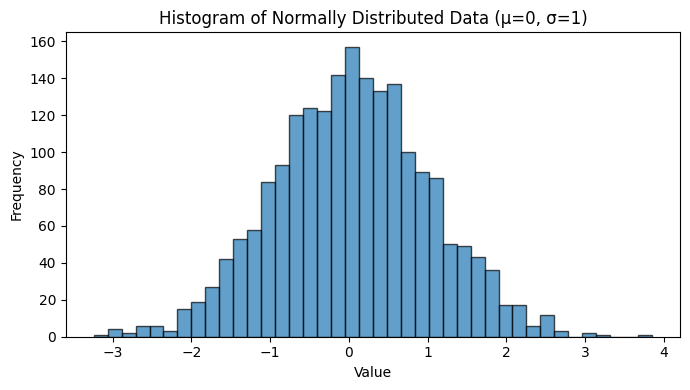

Skewness: 0.0227
Kurtosis (Fisher): 0.0735
Interpretation: distribution is approximately symmetric with ≈ normal kurtosis.


In [3]:
# Cell 2 — Exercise 2: normal distribution, histogram, skewness & kurtosis
# Generate data from a normal distribution
data = np.random.normal(loc=0.0, scale=1.0, size=2000)

# Histogram
plt.figure(figsize=(7,4))
plt.hist(data, bins=40, edgecolor="black", alpha=0.7)
plt.title("Histogram of Normally Distributed Data (μ=0, σ=1)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Use pandas for skewness & kurtosis
s = pd.Series(data)
skewness = s.skew()          # ~0 for perfect normal
kurtosis = s.kurtosis()      # Fisher’s definition: normal ≈ 0
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis (Fisher): {kurtosis:.4f}")

# Quick interpretation
if abs(skewness) < 0.1:
    skew_interp = "approximately symmetric"
elif skewness > 0:
    skew_interp = "right-skewed (longer right tail)"
else:
    skew_interp = "left-skewed (longer left tail)"

if abs(kurtosis) < 0.1:
    kurt_interp = "≈ normal kurtosis"
elif kurtosis > 0:
    kurt_interp = "leptokurtic (heavier tails/peaked)"
else:
    kurt_interp = "platykurtic (lighter tails/flatter)"

print(f"Interpretation: distribution is {skew_interp} with {kurt_interp}.")


Observed (1-12): [109 153 151 247 259 469 113 277 465 152 434 121]
Linear model: y = a*x + b with a=12.08, b=167.29
Forecast (13-18): [324.4 336.5 348.5 360.6 372.7 384.8]


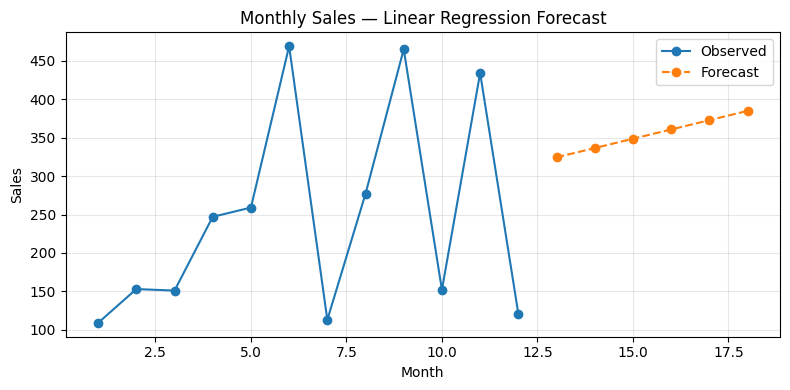

In [4]:
# Cell 3 — Exercise 3: simple forecasting with linear regression (NumPy polyfit)
# Given monthly sales data (12 months)
monthly_sales_data = np.random.randint(100, 500, size=12)

# Build indices for months 1..12
x = np.arange(1, 13, dtype=float)
y = monthly_sales_data.astype(float)

# Fit a straight line y = a*x + b using NumPy
a, b = np.polyfit(x, y, deg=1)

# Forecast next 6 months (months 13..18)
x_future = np.arange(13, 19, dtype=float)
y_future = a * x_future + b

print("Observed (1-12):", monthly_sales_data)
print("Linear model: y = a*x + b with a=%.2f, b=%.2f" % (a, b))
print("Forecast (13-18):", np.round(y_future, 1))

# Plot
plt.figure(figsize=(8,4))
plt.plot(x, y, marker="o", label="Observed")
plt.plot(x_future, y_future, marker="o", linestyle="--", label="Forecast")
plt.title("Monthly Sales — Linear Regression Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
# Cell 4 — Exercise 4: group & aggregate with Pandas
data = {
    'Product': ['Product A', 'Product B', 'Product C', 'Product A', 'Product B'],
    'Sales':   [200,         150,         300,         250,         180        ],
    'Month':   ['January',   'February',  'March',     'April',     'May'      ]
}
df = pd.DataFrame(data)
display(df)

# Group by Product: sum, mean, count
summary_by_product = df.groupby('Product')['Sales'].agg(['sum','mean','count']).reset_index()
print("Summary by Product:")
display(summary_by_product)

# Group by Month (keep order via Categorical, optional)
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
summary_by_month = df.groupby('Month', observed=False)['Sales'].agg(['sum','mean','count']).reset_index()
print("Summary by Month:")
display(summary_by_month.dropna())


,Product,Sales,Month
0,Product A,200,January
1,Product B,150,February
2,Product C,300,March
3,Product A,250,April
4,Product B,180,May


Summary by Product:


,Product,sum,mean,count
0,Product A,450,225.0,2
1,Product B,330,165.0,2
2,Product C,300,300.0,1


Summary by Month:


,Month,sum,mean,count
0,January,200,200.0,1
1,February,150,150.0,1
2,March,300,300.0,1
3,April,250,250.0,1
4,May,180,180.0,1


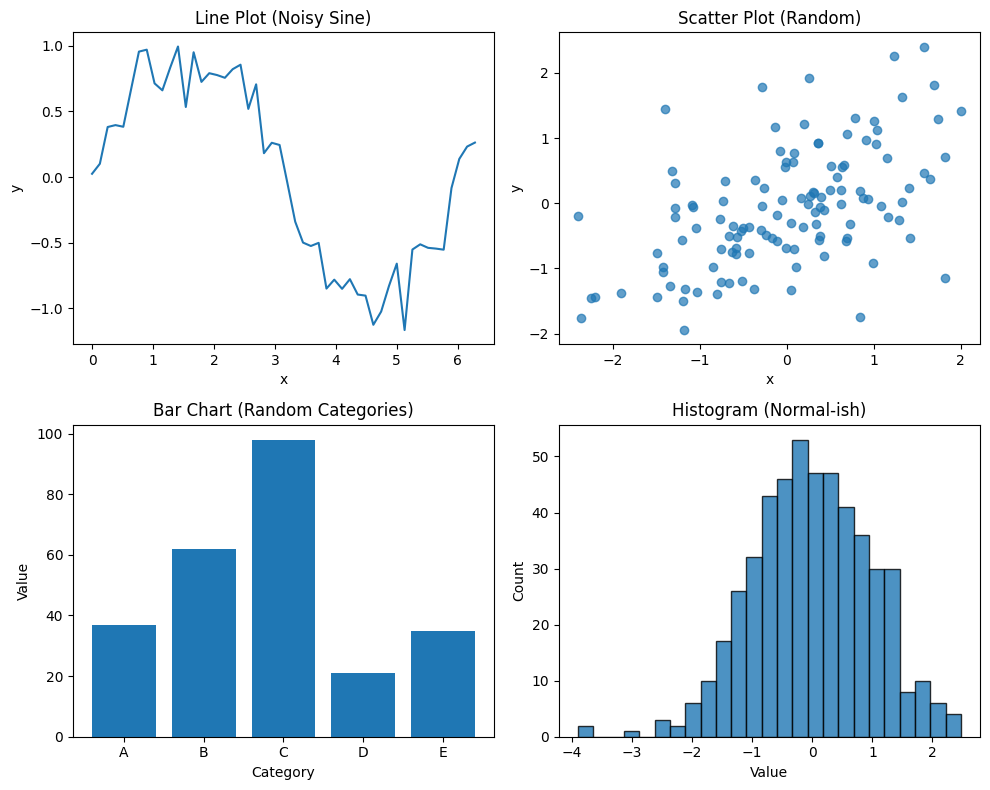

In [6]:
# Cell 5 — Exercise 5: multi-plot layout — line, scatter, bar using NumPy-generated data
rng = np.random.default_rng(0)

# Data
x = np.linspace(0, 2*np.pi, 50)
y_line = np.sin(x) + 0.2 * rng.normal(size=len(x))
x_scatter = rng.normal(loc=0, scale=1, size=120)
y_scatter = 0.5 * x_scatter + rng.normal(scale=0.7, size=120)
cats = ['A','B','C','D','E']
vals = rng.integers(10, 100, size=len(cats))

# Layout 2×2
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (1) Line plot
axes[0,0].plot(x, y_line, marker="", linewidth=1.5)
axes[0,0].set_title("Line Plot (Noisy Sine)")
axes[0,0].set_xlabel("x")
axes[0,0].set_ylabel("y")

# (2) Scatter plot
axes[0,1].scatter(x_scatter, y_scatter, alpha=0.7)
axes[0,1].set_title("Scatter Plot (Random)")
axes[0,1].set_xlabel("x")
axes[0,1].set_ylabel("y")

# (3) Bar chart
axes[1,0].bar(cats, vals)
axes[1,0].set_title("Bar Chart (Random Categories)")
axes[1,0].set_xlabel("Category")
axes[1,0].set_ylabel("Value")

# (4) Histogram
hist_data = rng.normal(0, 1, size=500)
axes[1,1].hist(hist_data, bins=25, edgecolor="black", alpha=0.8)
axes[1,1].set_title("Histogram (Normal-ish)")
axes[1,1].set_xlabel("Value")
axes[1,1].set_ylabel("Count")

plt.tight_layout()
plt.show()
